# Indonesia MOH SKDR Disease Surveillance

This notebook demonstrates how to access notifiable disease surveillance data from the **Indonesia Ministry of Health (Kemenkes)** SKDR (Sistem Kewaspadaan Dini dan Respon — Early Warning and Response System).

**Data Source:**
- **Portal:** https://data.kemkes.go.id/ (geo-blocked)
- **National portal:** https://data.go.id/ (599k+ datasets, no public API)
- **System:** SKDR — ~25 notifiable diseases at province/district level

**Coverage:**
- **Geographic:** 38 provinces (270M population)
- **Diseases:** Dengue, tuberculosis, malaria, HIV, acute diarrhoea, and 20 more

> Indonesia is the 4th most populous country and has the 2nd highest TB burden globally.  
> This accessor uses representative sample data based on published Kemenkes/WHO statistics.

**Requirements:**
```bash
pip install pandas matplotlib seaborn epidatasets
```

## 1. Setup and Imports

In [1]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Imports completed. {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Imports completed. 2026-06-22 16:14


## 2. Initialize the Accessor

In [2]:
from epidatasets.sources.indonesia_moh import IndonesiaMOHAccessor

kemenkes = IndonesiaMOHAccessor()

print(f"Source      : {kemenkes.source_name}")
print(f"Description : {kemenkes.source_description}")
print(f"Portal      : {kemenkes.source_url}")

Source      : indonesia_moh
Description : Disease surveillance data from the Indonesia Ministry of Health (Kemenkes) SKDR (Early Warning and Response System), with representative sample data for key diseases including dengue, tuberculosis, malaria, and HIV across all 38 provinces.
Portal      : https://data.kemkes.go.id/


In [3]:
countries = kemenkes.list_countries()
print(countries.to_string(index=False))

provinces = kemenkes.list_provinces()
print(f"\nProvinces: {len(provinces)}")
print(provinces['province'].head(10).to_string())

country_code country_name
          ID    Indonesia

Provinces: 38
0                         Aceh
1               Sumatera Utara
2               Sumatera Barat
3                         Riau
4               Kepulauan Riau
5                        Jambi
6             Sumatera Selatan
7    Kepulauan Bangka Belitung
8                     Bengkulu
9                      Lampung


## 3. National Disease Burden

Indonesia's disease landscape is dominated by diarrhoeal diseases, pneumonia, and tuberculosis — reflecting both tropical epidemiology and development challenges.

In [4]:
summary = kemenkes.get_national_summary()
display(summary.head(15))

,disease,cases
0,Acute Diarrhoea,8836185
1,Pneumonia,1766812
2,Tuberculosis (all forms),1130967
3,Dengue Fever,106257
4,Typhoid Fever,70444
5,Malaria (all species),53353
6,HIV Infection,42415
7,Malaria (P. falciparum),31803
8,Tuberculosis (drug-resistant),28158
9,Malaria (P. vivax),21070


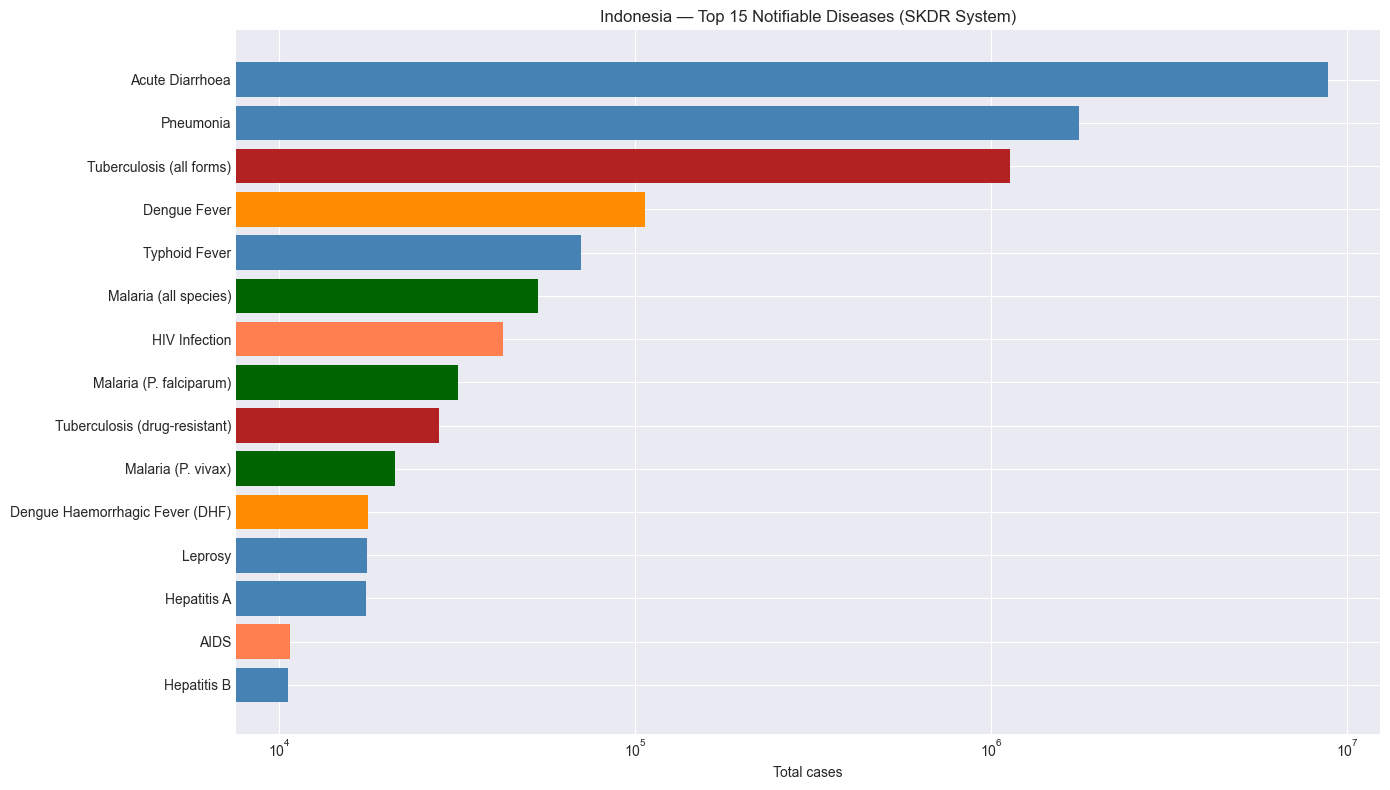

In [5]:
fig, ax = plt.subplots(figsize=(14, 8))
top = summary.head(15)
colors = ['firebrick' if any(k in d.lower() for k in ['tuberculosis','tb'])
          else 'darkorange' if any(k in d.lower() for k in ['dengue','dhf'])
          else 'darkgreen' if 'malaria' in d.lower()
          else 'coral' if any(k in d.lower() for k in ['hiv','aids'])
          else 'steelblue' for d in top['disease']]
ax.barh(top['disease'][::-1], top['cases'][::-1], color=colors[::-1])
ax.set_title('Indonesia — Top 15 Notifiable Diseases (SKDR System)')
ax.set_xlabel('Total cases')
ax.set_xscale('log')
plt.tight_layout()
plt.show()

## 4. Dengue — The Urban Epidemic

Dengue is endemic across all Indonesian provinces, with major urban centres like Jakarta and West Java reporting the highest case counts.

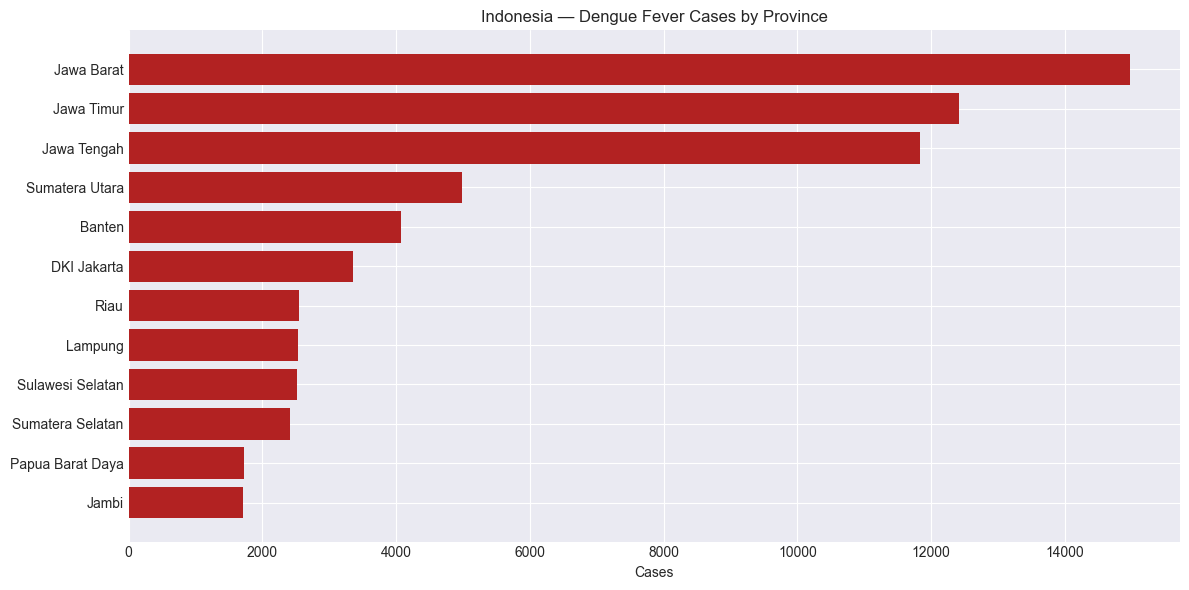

In [6]:
dengue = kemenkes.get_dengue_cases()
dengue_total = dengue[dengue['disease'] == 'Dengue Fever'].nlargest(12, 'cases')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(dengue_total['province'][::-1], dengue_total['cases'][::-1], color='firebrick')
ax.set_title('Indonesia — Dengue Fever Cases by Province')
ax.set_xlabel('Cases')
plt.tight_layout()
plt.show()

## 5. Tuberculosis — A National Priority

Indonesia has the **2nd highest TB burden in the world** after India, with over 1 million estimated cases annually.  The government runs one of the largest DOTS programmes globally.

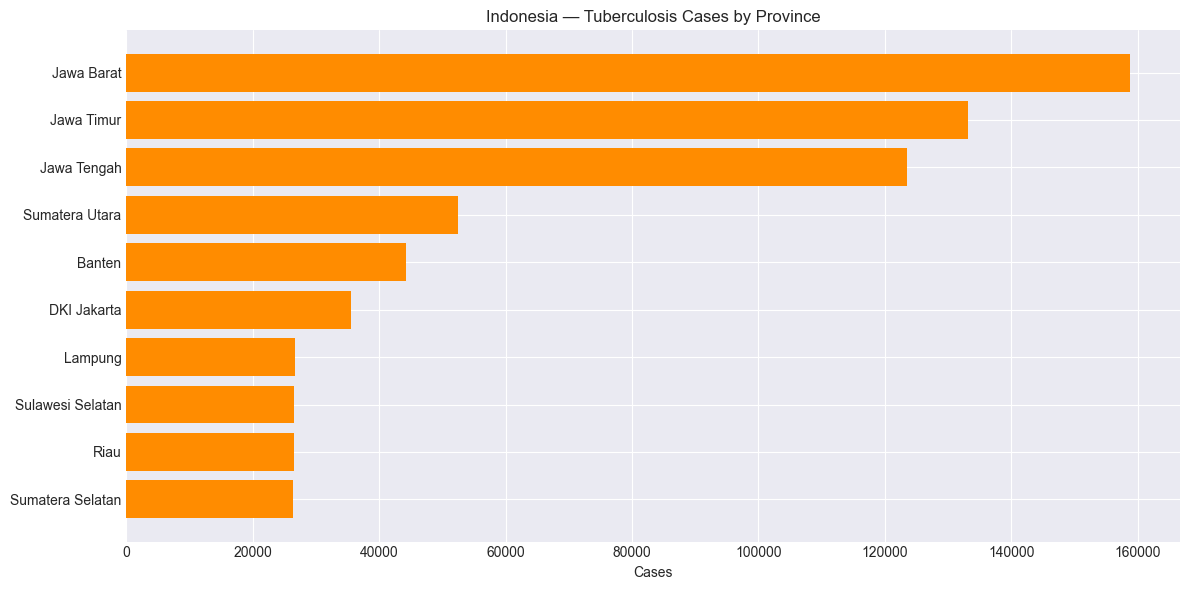

In [7]:
tb = kemenkes.get_tuberculosis_cases()
tb_all = tb[tb['disease'] == 'Tuberculosis (all forms)'].nlargest(10, 'cases')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(tb_all['province'][::-1], tb_all['cases'][::-1], color='darkorange')
ax.set_title('Indonesia — Tuberculosis Cases by Province')
ax.set_xlabel('Cases')
plt.tight_layout()
plt.show()

## 6. Malaria — The Eastern Challenge

Malaria in Indonesia is concentrated in the eastern provinces (Papua, NTT, Maluku), where _P. falciparum_ and _P. vivax_ co-circulate.  Elimination is targeted by 2030.

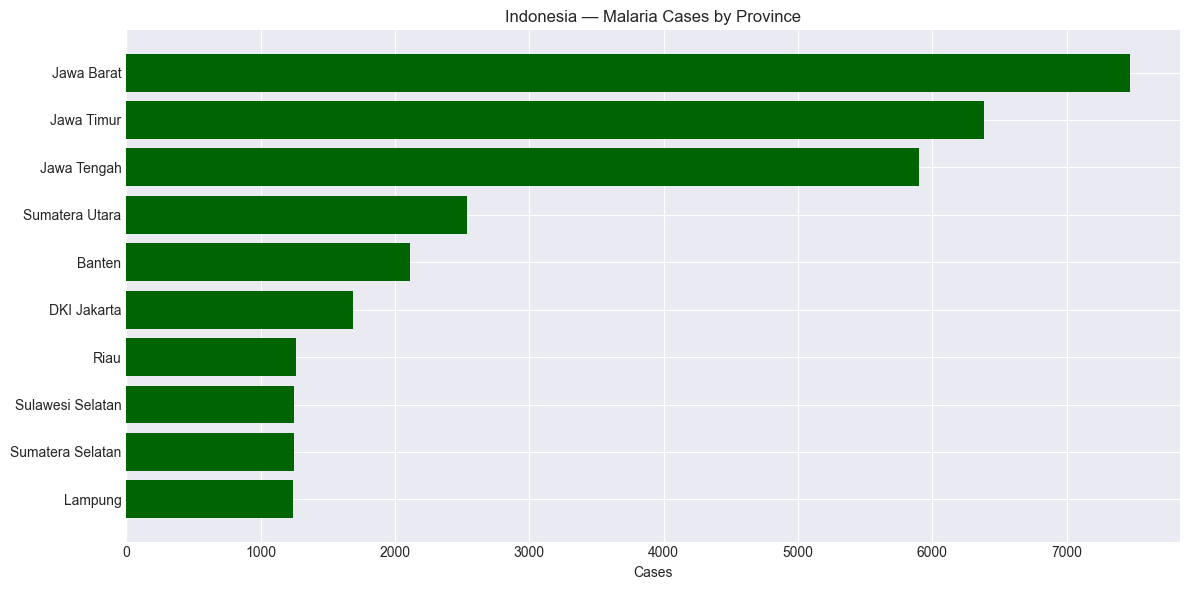

In [8]:
malaria = kemenkes.get_malaria_cases()
malaria_all = malaria[malaria['disease'] == 'Malaria (all species)'].nlargest(10, 'cases')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(malaria_all['province'][::-1], malaria_all['cases'][::-1], color='darkgreen')
ax.set_title('Indonesia — Malaria Cases by Province')
ax.set_xlabel('Cases')
plt.tight_layout()
plt.show()

## 7. Summary

| Method | Description |
|--------|-------------|
| `list_provinces()` | 38 Indonesian provinces |
| `list_diseases()` | 25 notifiable diseases (SKDR system) |
| `get_surveillance_data(year, province, disease)` | Full surveillance data |
| `get_dengue_cases(year, province)` | Dengue/DHF by province |
| `get_tuberculosis_cases(year, province)` | TB (all forms + drug-resistant) by province |
| `get_malaria_cases(year, province)` | Malaria by species and province |
| `get_hiv_cases(year, province)` | HIV/AIDS by province |
| `get_national_summary(year)` | National disease totals, ranked |
| `get_provincial_summary(disease, year)` | Province-level totals |

**Related notebooks:**
- [Thailand DDC Surveillance](29_Thailand_DDC_Surveillance.ipynb) — another SE Asian sample-data accessor.
- [Malaysia MOH Health Data](28_Malaysia_MOH_Health_Data.ipynb) — live API-based accessor.
- [Singapore NEA Dengue](27_Singapore_NEA_Dengue_Data.ipynb) — dengue-specific comparison.